In [ ]:
###
    # This code plots the seasonal cycle of active layer thickness (ALT) in northern Eurasian permafrost simulated by CMIP6 models.
    # Read the ALT data calculated from "../Process/01_ALT_monthly.jl", which saved in directory "../Data/cmip6_alt_m15_NH45_1850_2100/"
    # Compute the area-weighted average over the maximum permafrost region of northern Eurasia, and calculate monthly means during the historical period (1982-2014).
    # Output: Figure S4.
###

In [1]:
import pandas as pd
import numpy as np
from netCDF4 import Dataset
import glob
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import MultipleLocator
import warnings
warnings.filterwarnings("ignore")

In [ ]:
model = ["CESM2","CESM2-FV2","CESM2-WACCM","CNRM-CM6-1-HR","CNRM-CM6-1","CNRM-ESM2-1",
         "E3SM-1-1","FGOALS-f3-L","FGOALS-g3","GFDL-CM4","GFDL-ESM4","MIROC6","MIROC-ES2L",
         "MPI-ESM1-2-HR","MPI-ESM1-2-LR","NorESM2-LM","NorESM2-MM","TaiESM1"]
# Annual changes of 3.2m ALT and soil temperature of each model in historical period
alt1 = pd.DataFrame(columns = ['year','month'])
nmonths = 12*(2014-1982+1)
for j in range (nmonths):
    alt1.loc[j] = int(j/12)+1982
    alt1.month.loc[j] = j%12+1

for m in range (len(model)):
    modelname = model[m]
    filename1 = glob.glob("../Data/cmip6_alt_m15_NH45_1850_2100/"+modelname+"_alt_monthly_hd.nc")
    f = Dataset(filename1[0])
    alt = f["alt"][:] # 1982-2014
    alt1[modelname] = alt

# Create a new dataframe to store the monthly average ALT/Ts
alt_monthly = alt1.iloc[:12,:]
df1 = alt1.groupby(['month'])
df2 = [df1.get_group(x) for x in df1.groups]

for i in range(len(df2)):
    alt_monthly.loc[i] = df2[i].mean()
alt_monthly = alt_monthly.drop(labels = ['year'],axis = 1)

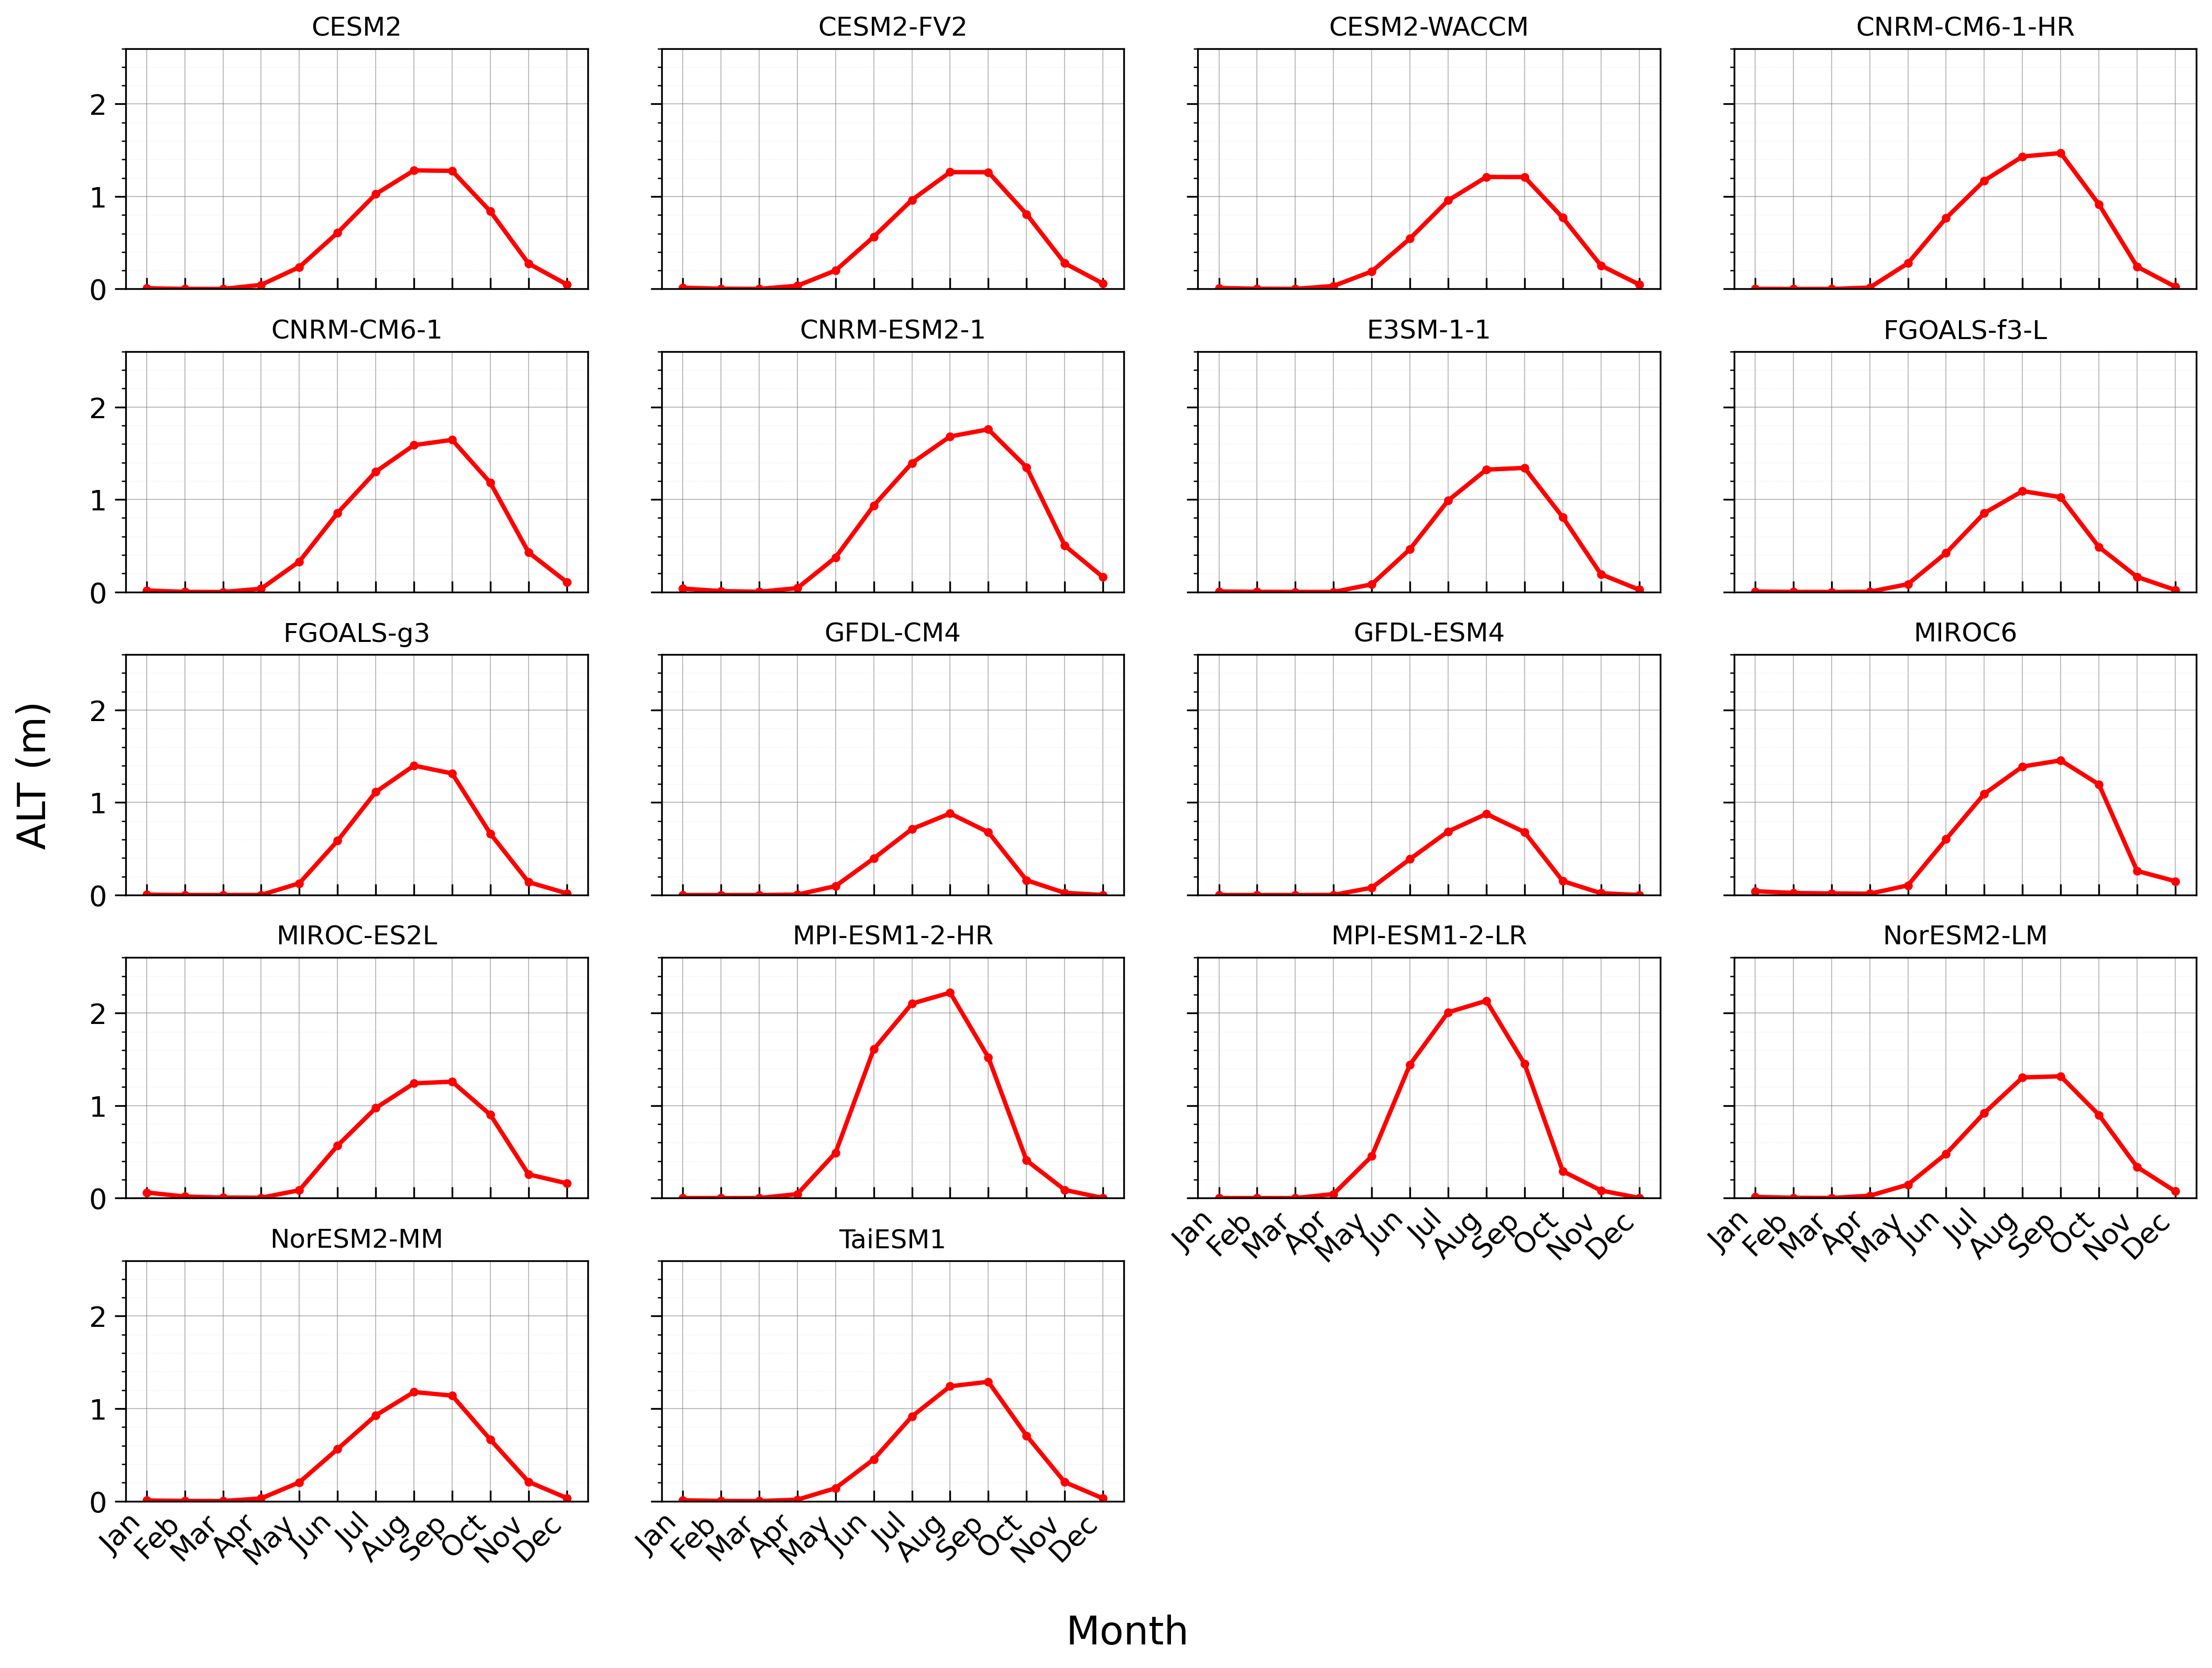

In [11]:
fig, axs = plt.subplots(5, 4, figsize=(17, 12), sharex=True, sharey=True,
                        gridspec_kw={'wspace': 0.16, 'hspace': 0.26}, dpi=300)

# Define month labels
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
          'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

for i, ax1 in enumerate(axs.flat[:18]):
    modelname = model[i]
    ax1.plot(np.linspace(1, 12, 12), 
             np.array(alt_monthly[modelname]),
             ls='-', marker='.', linewidth=2, c='red', label='ALT')
    
    # Set y-axis ticks
    y_major_locator = MultipleLocator(1)
    y_minor_locator = MultipleLocator(0.2)
    ax1.yaxis.set_major_locator(y_major_locator)
    ax1.yaxis.set_minor_locator(y_minor_locator)
    ax1.tick_params(axis='y', direction='out', which='major', length=5)
    ax1.tick_params(axis='y', direction='out', which='minor', length=2)
    
    # Set x-axis ticks (positions and labels)
    x_major_locator = MultipleLocator(1)
    x_minor_locator = MultipleLocator(4)
    ax1.xaxis.set_major_locator(x_major_locator)
    ax1.xaxis.set_minor_locator(x_minor_locator)
    ax1.set_xticks(range(1, 13))  # Set tick positions to 1-12
    ax1.set_xticklabels(months, rotation=45, ha='right')  # Set labels to month abbreviations
    
    ax1.tick_params(axis='x', direction='in', which='major', length=5)
    ax1.tick_params(axis='x', direction='in', which='minor', length=0)
    ax1.tick_params(axis='x', labelsize=10)  # Adjust x-axis label font size
    
    ax1.set_title(modelname, fontsize=12)
    ax1.tick_params(axis='y', labelsize=13)
    ax1.set_ylim((0, 2.6))
    
    # Add grid lines
    ax1.grid(True, which='major', linestyle='-', linewidth=0.5, alpha=0.5, color='gray')
    ax1.grid(True, which='minor', linestyle=':', linewidth=0.3, alpha=0.5, color='lightgray')
    
    for axis in ['top', 'bottom', 'left', 'right']:
        ax1.spines[axis].set_linewidth(0.8)
    
    if i == 8:
        ax1.set_ylabel('ALT (m)', fontsize=18, labelpad=16)

# Remove unwanted subplots
for j in range(18, 20):
    fig.delaxes(axs.flat[j])

for n in range(2):
    axs[3, n+2].tick_params(axis='both', which='both', labelbottom=True, labelsize=13)
axs[4, 0].tick_params(axis='both', which='both', labelbottom=True, labelsize=13)
axs[4, 1].tick_params(axis='both', which='both', labelbottom=True, labelsize=13)

fig.text(0.5, 0.04, 'Month', ha='center', va='center', fontsize=18)
fig.tight_layout(pad=0.2)
plt.show()

In [ ]:
fig.savefig("../Figures/FigureS4.png", bbox_inches='tight',dpi=300)